# Затухание и взрыв градиентов

In [ ]:
from tqdm.auto import tqdm
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.nn.utils import clip_grad_norm_
from torch.optim import SGD

from torchvision import transforms
from torchvision.datasets import MNIST

sns.set(palette="Set2")
set2_colors = sns.color_palette("Set2")

## Затухание градиентов

В прошлом семестре на курсе "Введение в анализ данных" была задача обучить полносвязную нейронную сеть c 99 слоями `Linear` и функцией активации `Tanh`. Давайте построим и обучим такую модель, а также сравним с менее глубокими сетями.

Будем использовать выборку из датасета MNIST, причем для простоты эксперимента ограничимся только двумя классами: 0 и 1.

In [ ]:
def load_mnist(
    train_size: int = 6000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels

In [ ]:
train_images, train_labels, test_images, test_labels = load_mnist()

def filter_data(images, labels):
    """Оставляем классы 0 и 1"""
    mask = labels <= 1
    return images[mask], labels[mask]

train_images, train_labels = filter_data(train_images, train_labels)
test_images, test_labels = filter_data(test_images, test_labels)

Реализуем код для построения полносвязной нейронной сети произвольной глубины.

In [ ]:
class SimpleModule(nn.Module):
    """
    Простой модуль, состоящий из линейного слоя, функции активации
    и опционального слоя пакетной нормализации (BatchNorm).

    Этот класс является удобным строительным блоком для создания
    более сложных многослойных сетей.

    Args:
        in_features (int): Количество входных признаков (размерность входа).
        out_features (int): Количество выходных признаков (размерность выхода).
        nonlinear (nn.Module, optional): Функция активации, применяемая после
            линейного слоя и BatchNorm. По умолчанию: nn.Tanh().
        use_bn (bool, optional): Флаг, указывающий, следует ли использовать
            слой BatchNorm1d. По умолчанию: False.
    """
    def __init__(self, in_features, out_features, nonlinear=None, use_bn=False):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

        if use_bn:
            self.bn = nn.BatchNorm1d(out_features)
        else:
            self.bn = nn.Identity()

        if nonlinear is not None:
            self.nonlinear = nonlinear
        else:
            self.nonlinear = nn.Identity()

    def forward(self, x):
        x = self.linear(x)
        x = self.bn(x)
        x = self.nonlinear(x)
        return x


def create_model(
        in_features=196,
        hidden_features=10,
        out_features=2,
        layers=2,
        nonlinear=nn.Tanh(),
        use_bn=False,
        device="cpu"
):
    """
    Создает многослойную нейронную сеть (MLP) с использованием SimpleModule.

    Функция-фабрика, которая конструирует последовательную модель (nn.Sequential)
    из заданного количества слоев. Модель состоит из входного слоя,
    нескольких (возможно, нуля) скрытых слоев и выходного линейного слоя.

    Args:
        in_features (int, optional): Размерность входного вектора. По умолчанию 196.
        hidden_features (int, optional): Размерность скрытых слоев. По умолчанию 10.
        out_features (int, optional): Размерность выходного вектора. По умолчанию 2.
        layers (int, optional): Общее количество слоев. Должно быть не менее 2
            (входной и выходной). По умолчанию 2.
        nonlinear (nn.Module, optional): Функция активации для скрытых слоев.
            По умолчанию nn.Tanh().
        use_bn (bool, optional): Использовать ли BatchNorm в скрытых слоях.
            По умолчанию False.
        device (Union[str, torch.device], optional): Устройство для размещения
            модели ('cpu' или 'cuda'). По умолчанию 'cpu'.

    Returns:
        nn.Sequential: Готовая модель, перенесенная на указанное устройство.
    """
    assert layers >= 2
    model = nn.Sequential()

    # Входной слой
    model.append(SimpleModule(in_features, hidden_features, nonlinear=nonlinear, use_bn=use_bn))

    # Промежуточные слои
    for i in range(layers - 2):
       model.append(SimpleModule(hidden_features, hidden_features, nonlinear=nonlinear, use_bn=use_bn))

    # Выходной слой
    model.append(SimpleModule(hidden_features, out_features, nonlinear=None, use_bn=False))
    model.to(device)
    return model

Распишем цикл обучения сети. Будем обучать в течение 30 эпох, использовать батч размера 32 и функцию ошибки кросс-энтропию.

In [ ]:
batch_size = 32
n_epochs = 30
criterion = nn.CrossEntropyLoss()

def train_model(model, optimizer, device="cpu", max_clip_grad_norm=None, desc=None):
    """
    Обучает модель на случайных батчах из тренировочных данных.

    Функция выполняет обучение модели в течение заданного количества эпох,
    на каждой итерации случайным образом выбирая батч из тренировочных данных.
    Поддерживает отсечение градиентов для предотвращения взрыва градиентов.

    Parameters
    ----------
    model : torch.nn.Module
        Модель PyTorch для обучения
    optimizer : torch.optim.Optimizer
        Оптимизатор для обновления параметров модели
    device : str, optional
        Устройство для вычислений ('cpu' или 'cuda'), по умолчанию 'cpu'
    max_clip_grad_norm : float, optional
        Максимальная норма для отсечения градиентов, по умолчанию None
    desc : str, optional
        Описание для progress bar (tqdm), по умолчанию None

    Returns
    -------
    list
        История значений функции потерь на каждой итерации обучения
    """
    loss_history = []
    for epoch in tqdm(range(n_epochs), desc=desc):
        # Проходимся столько раз (40), сколько батчей умещается в датасет
        for i in range(40):
          # Выбираем случ. индексы для тренировочных данных
          idx = np.random.randint(0, len(train_labels), batch_size)
          # Собираем батч
          images, labels = train_images[idx], train_labels[idx]
          # Получаем предсказания
          logits = model(images.to(device))
          # Считаем ошибку
          loss = criterion(logits, labels)
          # Делаем обратный проход
          loss.backward()
          # Если необходимо, обрезаем градиенты (будет нужно позднее)
          if max_clip_grad_norm is not None:
              clip_grad_norm_(model.parameters(), max_norm=100.0)
          # Оптимизационный шаг
          optimizer.step()
          # Обнуляем градиенты
          optimizer.zero_grad()
          # Обновляем историю
          loss_history.append(loss.item())
    return loss_history

Для удобства также определим пайплайн эксперимента в виде функции. Наши данные довольно скромные и эксперимент спокойно запускается на CPU.

In [ ]:
device = "cpu"
lr = 0.1

def make_experiment(
        layers,
        nonlinear=nn.Tanh(),
        use_bn=False,
        init_weights=None,
        max_clip_grad_norm=None,
        desc=None
    ):
    """
    Проводит эксперимент по обучению нейронной сети с заданными параметрами.

    Функция создает, инициализирует и обучает модель нейронной сети с указанной
    архитектурой и гиперпараметрами. Возвращает обученную модель и историю потерь.

    Parameters
    ----------
    layers : list of int
        Список, определяющий архитектуру сети. Каждый элемент - количество
        нейронов в соответствующем слое. Например: [784, 128, 64, 10]
    nonlinear : torch.nn.Module, optional
        Функция активации для скрытых слоев, по умолчанию nn.Tanh()
    use_bn : bool, optional
        Флаг использования batch normalization, по умолчанию False
    init_weights : callable, optional
        Функция для инициализации весов модели, по умолчанию None
    max_clip_grad_norm : float, optional
        Максимальная норма для отсечения градиентов, по умолчанию None
    desc : str, optional
        Описание эксперимента для progress bar, по умолчанию None

    Returns
    -------
    tuple
        Кортеж (model, loss_history), где:
        - model : torch.nn.Module - обученная модель
        - loss_history : list - история значений функции потерь на каждой итерации
    """
    # Создаем модель
    model = create_model(layers=layers, nonlinear=nonlinear, use_bn=use_bn, device=device)
    # Инициализируем веса, если указана функция для этого (будет нужно позднее)
    if init_weights is not None:
        model.apply(init_weights)
    # Передаем пар-ры модели в оптимизатор
    optimizer = SGD(model.parameters(), lr=lr)
    desc = f"{layers} слоев" if desc is None else desc
    # Проводим обучение
    loss_history = train_model(model, optimizer, max_clip_grad_norm=max_clip_grad_norm, desc=desc)
    return model, loss_history

Обучим полносвязные нейронные сети глубины 2, 10 и 99.

In [ ]:
model_2, history_2 = make_experiment(2)
model_10, history_10 = make_experiment(10)
model_99, history_99 = make_experiment(99)

2 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

10 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

99 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

Быстрее всего сошлась модель с 2 слоями. Следом за ней модель с 10 слоями. Модель 99 слоями не смогла обучиться. Посмотрим, что происходит с градиентами этих моделей.

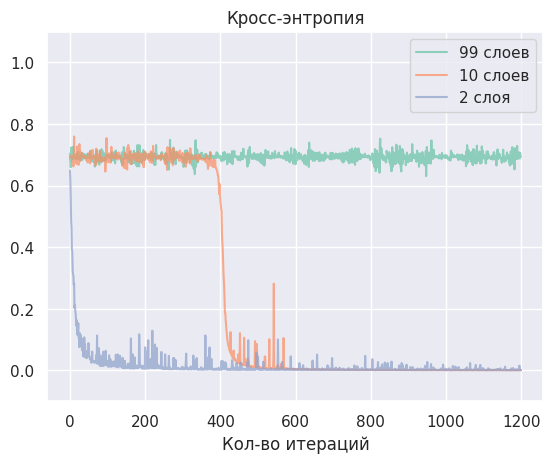

In [ ]:
plt.plot(history_99, label='99 слоев', alpha=0.7)
plt.plot(history_10, label='10 слоев', alpha=0.7)
plt.plot(history_2, label='2 слоя', alpha=0.7)
plt.legend()
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.ylim(-0.1, 1.1);

Значения лоссов на последней эпохе обучения у модели с 10 слоями оказались даже лучше чем у модели с 2 слоями.

In [ ]:
np.mean(history_2[-40]).round(6), np.mean(history_10[-40]).round(6)

(np.float64(0.001406), np.float64(0.000912))

Посмотрим, как распределяются нормы градиентов по слоям сети.

In [ ]:
def collect_grad(model):
  images, labels = train_images[:batch_size], train_labels[:batch_size]
  logits = model(images.to(device))
  loss = criterion(logits, labels)
  loss.backward()

  grad_norm = []
  for name, param in model.named_parameters():
      if name.find('linear.weight') != -1:
          grad_norm.append(param.grad.norm().item())
  return grad_norm

Модель с 99 слоями имеет очень характерное **затухание градиентов**. Неглубокие сети не старадают от нулевых градиентов, но норма градиента все же снижается к началу сети.

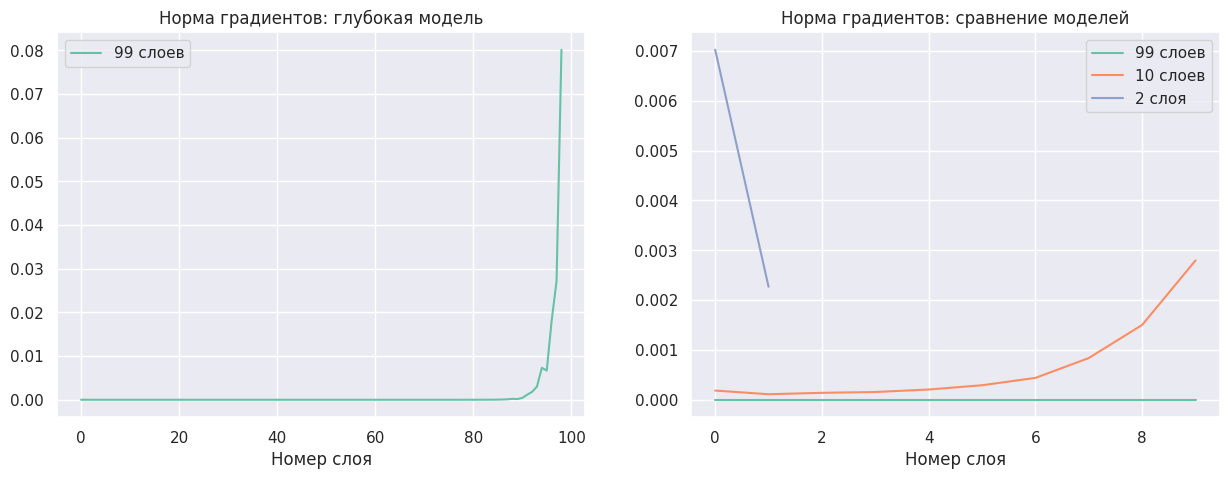

In [ ]:
grad_norm_99 = collect_grad(model_99)
grad_norm_10 = collect_grad(model_10)
grad_norm_2 = collect_grad(model_2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(grad_norm_99, label="99 слоев")
plt.legend()
plt.title("Норма градиентов: глубокая модель")
plt.xlabel('Номер слоя')

plt.subplot(1, 2, 2)
plt.plot(grad_norm_99[:10], label="99 слоев")
plt.plot(grad_norm_10, label="10 слоев")
plt.plot(grad_norm_2, label="2 слоя")
plt.legend(loc="upper right")
plt.title("Норма градиентов: cравнение моделей")
plt.xlabel('Номер слоя')

plt.show()

## А теперь разберем проблему затухания градиентов
```
  o     o     o                *------------------------------*   
 /|    /|    /|                | Лекция: Затухание градиентов |
 / L . / L . / L...............*------------------------------*
```

Рассмотрим глубокие сети с 30 слоями. Оценим, как влияет функция активации на градиенты и сходимость сети. Рассмотрим функции `Tanh`, `ReLU` и `SilU` (она же SWISH из лекции).

In [ ]:
model_tanh, history_tanh = make_experiment(30, use_bn=False, nonlinear=nn.Tanh(), desc='tanh')
model_relu, history_relu = make_experiment(30, use_bn=False, nonlinear=nn.ReLU(), desc='relu')
model_silu, history_silu = make_experiment(30, use_bn=False, nonlinear=nn.SiLU(), desc='silu')

tanh:   0%|          | 0/30 [00:00<?, ?it/s]

relu:   0%|          | 0/30 [00:00<?, ?it/s]

silu:   0%|          | 0/30 [00:00<?, ?it/s]

Оказывается, что функция активации сама по себе не может решить проблему сходимости.

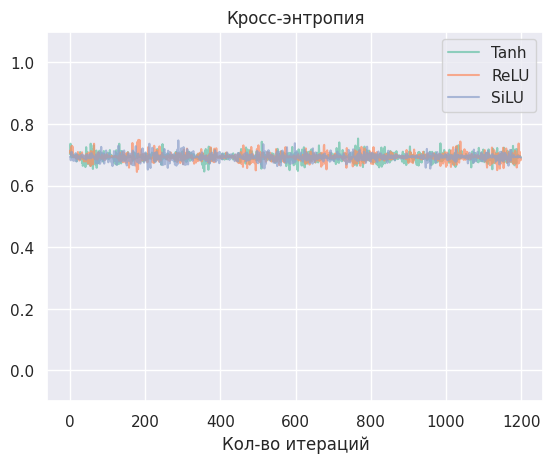

In [ ]:
plt.plot(history_tanh, label='Tanh', alpha=0.7)
plt.plot(history_relu, label='ReLU', alpha=0.7)
plt.plot(history_silu, label='SiLU', alpha=0.7)
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.legend()
plt.ylim(-0.1, 1.1);

Посчитаем нормы градиентов для полученных моделей.

In [ ]:
grad_norm_tanh = collect_grad(model_tanh)
grad_norm_relu = collect_grad(model_relu)
grad_norm_silu = collect_grad(model_silu)

Несмотря на то, что мы использовали хорошие функции активации, накопительный эффект малых градиентов все равно случился.

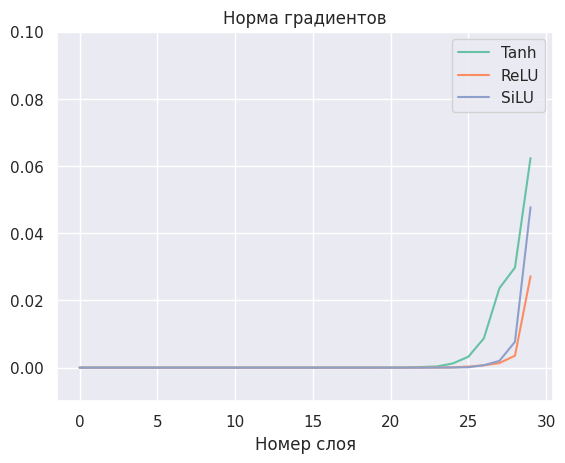

In [ ]:
plt.plot(grad_norm_tanh, label="Tanh")
plt.plot(grad_norm_relu, label="ReLU")
plt.plot(grad_norm_silu, label="SiLU")
plt.title("Норма градиентов")
plt.xlabel('Номер слоя')
plt.ylim(-0.01, 0.1)
plt.legend()
plt.show()

Добавим `BatchNorm`.

In [ ]:
model_tanh_bn, history_tanh_bn = make_experiment(30, use_bn=True, nonlinear=nn.Tanh())
model_relu_bn, history_relu_bn = make_experiment(30, use_bn=True, nonlinear=nn.ReLU())
model_silu_bn, history_silu_bn = make_experiment(30, use_bn=True, nonlinear=nn.SiLU())

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

Кажется, что сеть с `SiLU` лучше сошлась по сравнению с другими моделями. Но график получился очень шумным.

(-0.1, 1.1)

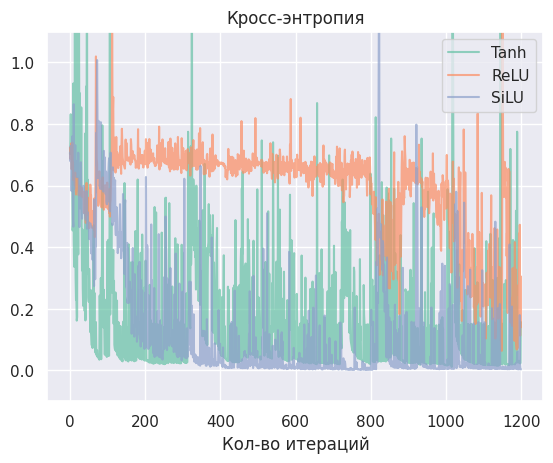

In [ ]:
plt.plot(history_tanh_bn, label='Tanh', alpha=0.7)
plt.plot(history_relu_bn, label='ReLU', alpha=0.7)
plt.plot(history_silu_bn, label='SiLU', alpha=0.7)
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.legend()
plt.ylim(-0.1, 1.1)

Добавим функцию сглаживания.

In [ ]:
def smooth_mean(x: np.ndarray, k: int = 10) -> np.ndarray:
    kernel = np.ones(2*k + 1) / (2*k + 1)
    y = np.convolve(x, kernel, mode='same')
    return y

Теперь точно видно, `SiLU` в комбинации в `BatchNorm` получилось решить проблему сходимости, что не скажешь по функции `Tanh` и `ReLU`.

(-0.1, 1.1)

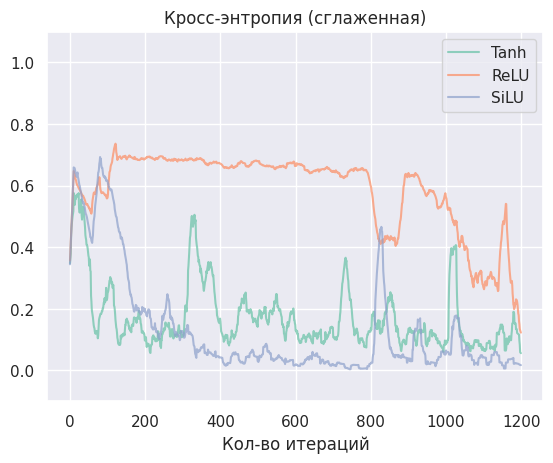

In [ ]:
plt.plot(smooth_mean(history_tanh_bn), label='Tanh', alpha=0.7)
plt.plot(smooth_mean(history_relu_bn), label='ReLU', alpha=0.7)
plt.plot(smooth_mean(history_silu_bn), label='SiLU', alpha=0.7)
plt.title("Кросс-энтропия (сглаженная)")
plt.xlabel("Кол-во итераций")
plt.legend()
plt.ylim(-0.1, 1.1)

Посчитаем нормы градиентов для полученных моделей.

In [ ]:
grad_norm_tanh_bn = collect_grad(model_tanh_bn)
grad_norm_relu_bn = collect_grad(model_relu_bn)
grad_norm_silu_bn = collect_grad(model_silu_bn)

Видим старую проблему `Tanh` с очень маленькими затухающими градиентами. У `ReLU` затухающих градиентов не видно, они даже наоборот получаются слишком большими, из-за чего модель не может сойтись к оптимуму. У `SiLU` все получилось как нужно.

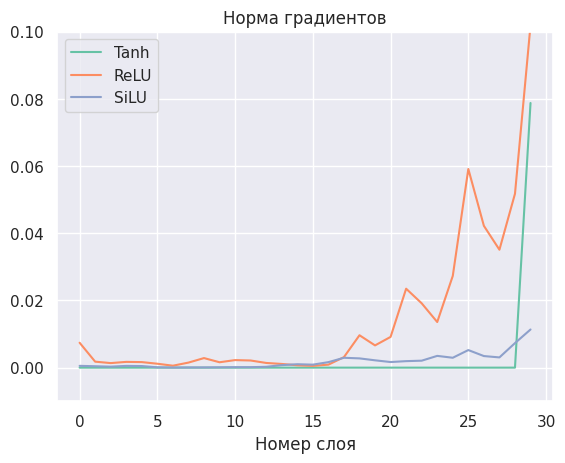

In [ ]:
plt.plot(grad_norm_tanh_bn, label="Tanh")
plt.plot(grad_norm_relu_bn, label="ReLU")
plt.plot(grad_norm_silu_bn, label="SiLU")
plt.title("Норма градиентов")
plt.xlabel('Номер слоя')
plt.ylim(-0.01, 0.1)
plt.legend()
plt.show()

## Пора узнать, какую магию сотворил `BatchNorm`.
```
  o     o     o                *------------------------------*   
 /|    /|    /|                | Лекция: BatchNorm            |
 / L . / L . / L...............*------------------------------*
```

## Взрыв градиентов

Теперь посмотрим, что будет, если мы немного **испортим веса**.

In [ ]:
new_std = 1

def init_weights_large(m):
    """Кастомная инициализация весов"""
    if isinstance(m, nn.Linear):
        # Инициализируем веса
        nn.init.normal_(m.weight, 0, new_std)
        nn.init.zeros_(m.bias)

In [ ]:
model_destr_30, history_destr_30 = make_experiment(30, nonlinear=nn.SiLU(), init_weights=init_weights_large)

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

Получили огромный лосс, который привел к **взрыву градиентов** и последуюшим nan в лоссе.

In [ ]:
history_destr_30[:5]

[2650583.5, nan, nan, nan, nan]

Покажем, что эффект от градиентов действительно накопительный. С такой же инициализацией обучим сеть глубины 2.

In [ ]:
model_destr_2, history_destr_2 = make_experiment(2, nonlinear=nn.SiLU(), init_weights=init_weights_large)

2 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

У модели глубины 2 нет взрыва, и лосс сходится с течением времени.

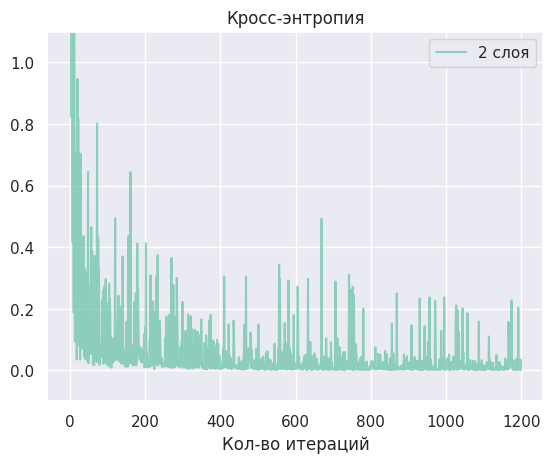

In [ ]:
plt.plot(history_destr_2, label='2 слоя', alpha=0.7)
plt.legend()
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.ylim(-0.1, 1.1);

Попробуем исправить взрыв градиентов, сделаем обрезку градиентов (grad clipping).

In [ ]:
model_destr_clip_30, history_destr_clip_30 = make_experiment(30, nonlinear=nn.SiLU(), init_weights=init_weights_large, max_clip_grad_norm=1)

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

Взрыва больше не наблюдается, однако и сойтись модель не может.

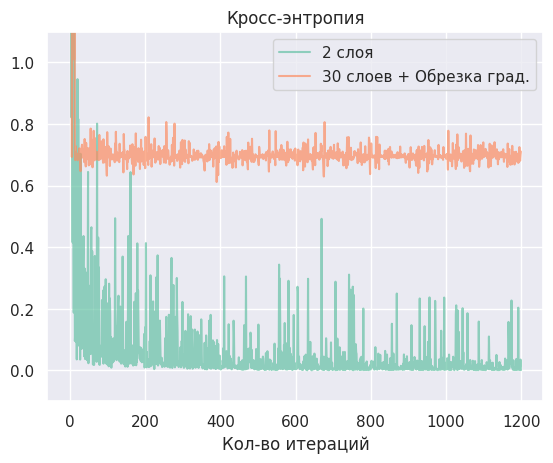

In [ ]:
plt.plot(history_destr_2, label='2 слоя', alpha=0.7)
plt.plot(history_destr_clip_30, label='30 слоев + Обрезка град.', alpha=0.7)
plt.legend()
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.ylim(-0.1, 1.1);

Посмотрим на градиенты, чтобы узнать почему так произошло. После отсечения градиентов мы снова столкнулись с проблемой затухающих градиентов.

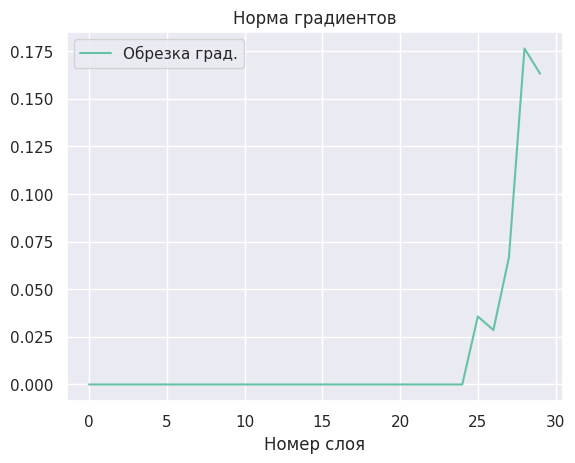

In [ ]:
grad_destr_clip_30 = collect_grad(model_destr_clip_30)
plt.plot(grad_destr_clip_30, label="Обрезка град.")
plt.title("Норма градиентов")
plt.xlabel('Номер слоя')
plt.legend();

В прошлый раз нам помогла `BatchNorm`. Применим ее и в этот раз.

In [ ]:
model_bn_destr_clip_30, history_bn_destr_clip_30 = make_experiment(30, nonlinear=nn.SiLU(), use_bn=True, init_weights=init_weights_large, max_clip_grad_norm=1)

30 слоев:   0%|          | 0/30 [00:00<?, ?it/s]

Теперь лосс начал сходиться к оптимуму.

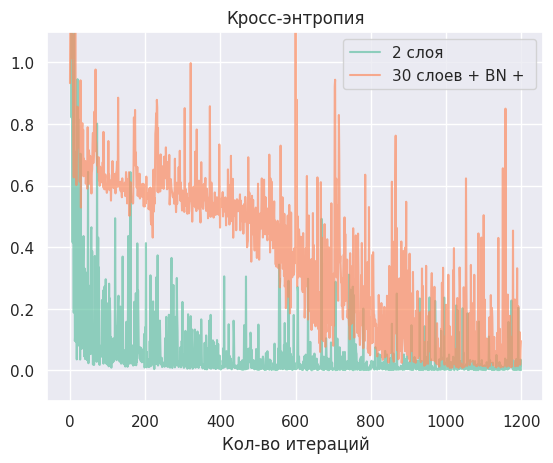

In [ ]:
plt.plot(history_destr_2, label='2 слоя', alpha=0.7)
plt.plot(history_bn_destr_clip_30, label='30 слоев + BN + ', alpha=0.7)
plt.legend()
plt.title("Кросс-энтропия")
plt.xlabel("Кол-во итераций")
plt.ylim(-0.1, 1.1);

И градиентам стало занчительно лучше.

Text(0.5, 0, 'Номер слоя')

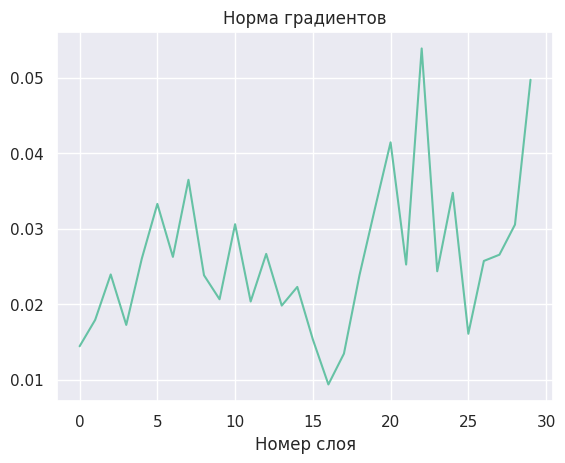

In [ ]:
grad_bn_destr_clip_30 = collect_grad(model_bn_destr_clip_30)
plt.plot(grad_bn_destr_clip_30, label="Clip Grad")
plt.title("Норма градиентов")
plt.xlabel('Номер слоя')

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока